## Explortory Data Analysis

In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU available      : True


# Finding the Dataset

In [4]:
#finds where Cat/ and Dog/ acctually are
# Detect the folder structure
import glob
# for temp storage
#data_root = Path('/content/data')

from google.colab import drive
drive.mount('/content/drive')
data_root = Path("/content/drive/MyDrive/cats_vs_dogs_classifier")

# Search for Cat and Dog folders (case-insensitive)
cat_dirs = list(data_root.rglob("[Cc]at")) + list(data_root.rglob("[Cc]ats"))
dog_dirs = list(data_root.rglob("[Dd]og")) + list(data_root.rglob("[Dd]ogs"))

Mounted at /content/drive


In [5]:
cat_dirs = [d for d in cat_dirs if d.is_dir()]
dog_dirs = [d for d in dog_dirs if d.is_dir()]

In [6]:
print("Found Cat folders: ", cat_dirs)
print("Found Dog folders: ", dog_dirs)

Found Cat folders:  [PosixPath('/content/drive/MyDrive/cats_vs_dogs_classifier/data/raw/PetImages/Cat')]
Found Dog folders:  [PosixPath('/content/drive/MyDrive/cats_vs_dogs_classifier/data/raw/PetImages/Dog')]


In [7]:
RAW_CAT_DIR = cat_dirs[0]
RAW_DOG_DIR = dog_dirs[0]
RAW_DIR = RAW_CAT_DIR.parent
print(f'\nRaw Cat folder {RAW_CAT_DIR}')
print(f'\nRaw Dog folder {RAW_DOG_DIR}')
print(f"\nRaw root       {RAW_DIR}")
print(f"\n     Cat images: {len(list(RAW_CAT_DIR.iterdir()))}")
print(f"\n     Dog images: {len(list(RAW_DOG_DIR.iterdir()))}")


Raw Cat folder /content/drive/MyDrive/cats_vs_dogs_classifier/data/raw/PetImages/Cat

Raw Dog folder /content/drive/MyDrive/cats_vs_dogs_classifier/data/raw/PetImages/Dog

Raw root       /content/drive/MyDrive/cats_vs_dogs_classifier/data/raw/PetImages

     Cat images: 12501

     Dog images: 12501


## understanding the data

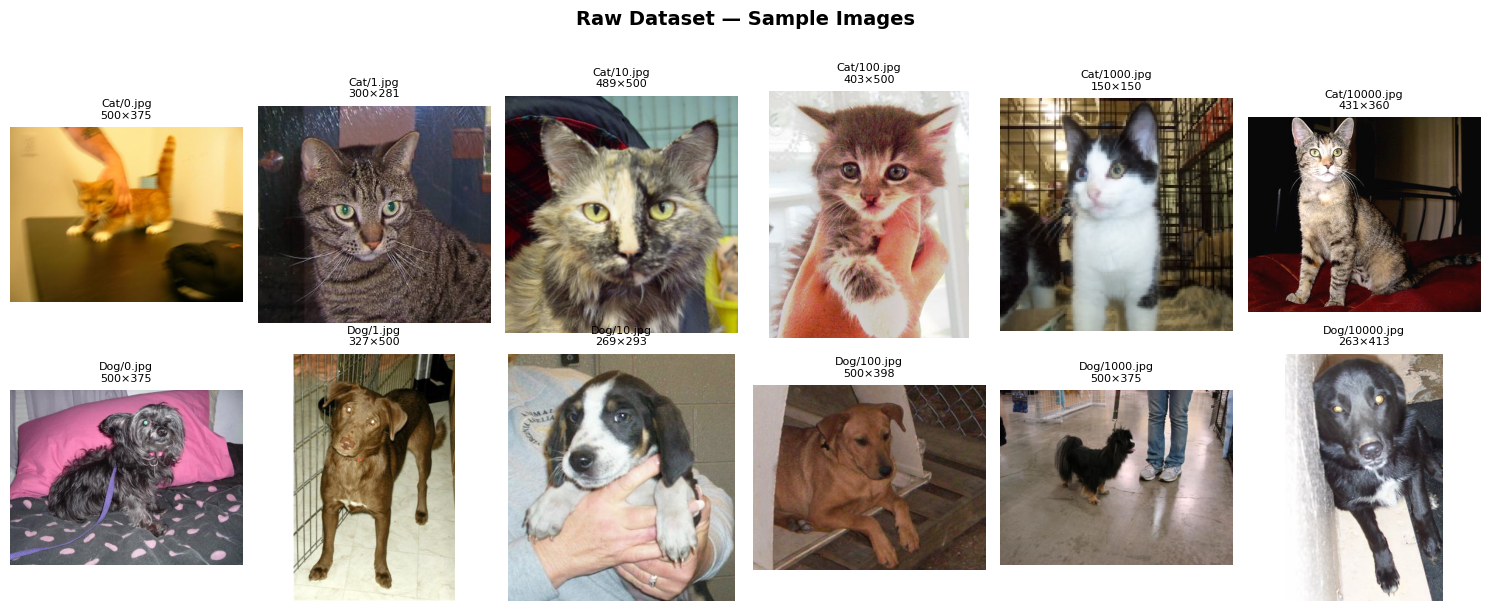

In [8]:
fig, axis = plt.subplots(2,6, figsize=(15,6))
fig.suptitle("Raw Dataset — Sample Images", fontsize=14, fontweight="bold", y=1.01)

for row, (cls_dir, cls_name) in enumerate([(RAW_CAT_DIR, "Cat"), (RAW_DOG_DIR, "Dog")]):
  files = sorted(cls_dir.iterdir())[:6]

  for col, fpath in enumerate(files):
    img = Image.open(fpath).convert("RGB")
    axis[row, col].imshow(img)
    axis[row, col].set_title(f"{cls_name}/{fpath.name}\n{img.size[0]}×{img.size[1]}",fontsize=8),
    axis[row, col].axis("off")
plt.tight_layout()
plt.show()